In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
Image_size = 256
Batch_size = 32
Channels = 3
Epochs =50
# 1. Sets image size to 256×256 pixels, batch size to 32, and color channels to 3 (RGB), defining input shape and training granularity.
# 2. Specifies 50 training epochs to allow the CNN sufficient time to learn complex patterns in rice leaf images.

## Data Loading from Directory

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Leaves",
    shuffle=True,
    image_size=(Image_size,Image_size),
    batch_size=Batch_size
)

Found 119 files belonging to 3 classes.


####  1. Loads rice leaf images from the 'Leaves' directory, automatically labeling them based on subfolder names.
####  2. Applies shuffling and resizes images to 256×256 with a batch size of 32, preparing data for model training.


In [ ]:
# Extracting Class Names from Dataset
class_names = dataset.class_names
class_names

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

#### Retrieves the list of class labels inferred from subdirectory names in the 'Leaves' folder.
####  Useful for decoding model predictions and displaying human-readable labels during evaluation and visualization.

In [ ]:
# Title: Inspecting a Batch from the Dataset
for image_batch , label_batch in dataset.take(1):
    print(image_batch.shape) #(batch_size, height, width, channels)
    print(label_batch.numpy()) #1D tensor like [0, 1, 2, ..., 0].

(32, 256, 256, 3)
[0 0 2 0 2 0 0 0 2 0 1 0 1 2 0 0 0 2 0 2 1 0 2 2 0 2 0 1 2 0 2 0]


#### 1. Prints the shape of one image batch to confirm input dimensions: (batch_size, height, width, channels).
#### 2. Displays corresponding label tensor to verify class encoding and ensure correct mapping for training.


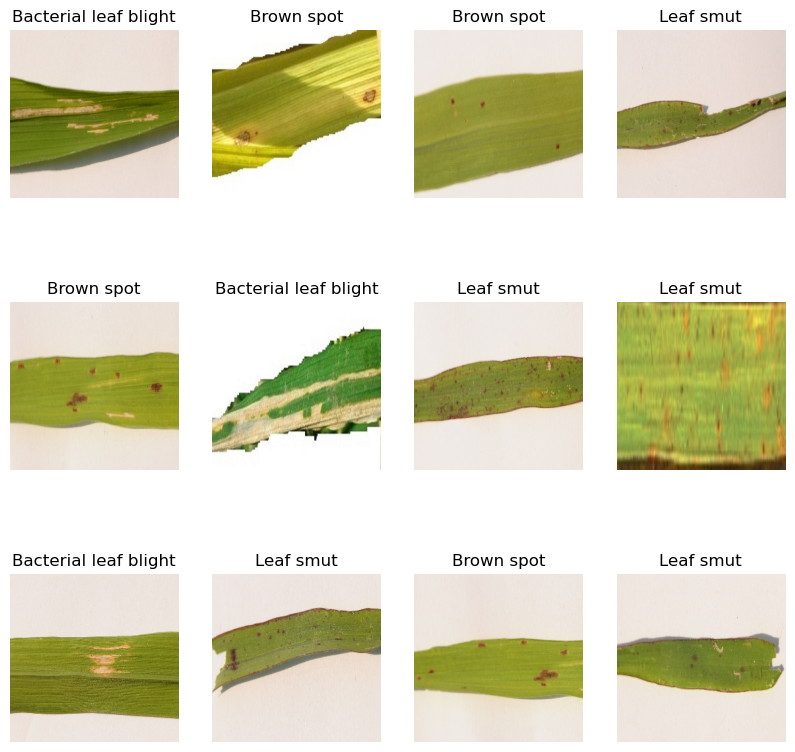

In [ ]:
#This code displays the first 12 images from one batch of the dataset with their corresponding class names.
plt.figure(figsize=(10,10))
for image_batch , label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")
        

#### Splitting Dataset into Train, Validation, and Test Sets

In [ ]:
import tensorflow as tf

IMAGE_SIZE = 256
BATCH_SIZE = 32
SEED = 123

# 1. Load 75% for training
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Leaves",
    validation_split=0.25,        # 25% goes to val+test
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# 2. Load 25% for splitting into val + test
val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Leaves",
    validation_split=0.25,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# 3. Split 25% into 50% val and 50% test
val_batches = int(len(val_test_ds) * 0.5)

val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)


Found 119 files belonging to 3 classes.
Using 90 files for training.
Found 119 files belonging to 3 classes.
Using 29 files for validation.


#### 1. Loads 75% of rice leaf images for training and reserves 25% for validation and testing using a fixed random seed for reproducibility.
#### 2. Further splits the 25% into equal halves for validation and test sets, ensuring balanced evaluation and tuning during model development.


In [ ]:
# Custom Dataset Partitioning Function
def get_dataset_partitions_tf(ds, train_split=0.7, val_split=0.15, test_split=0.15,
                              shuffle=True, shuffle_size=100):
    assert (train_split + val_split + test_split) == 1, "Splits must add up to 1"
    
    ds_size = len(ds)
    if ds_size < 3:
        raise ValueError("Dataset too small to split into 3 parts.")

    if shuffle:
        ds = ds.shuffle(buffer_size=shuffle_size, seed=123)

    train_size = max(1, int(train_split * ds_size))
    val_size = max(1, int(val_split * ds_size))
    test_size = ds_size - train_size - val_size

    # Adjust if overshooting total size
    if train_size + val_size + test_size > ds_size:
        test_size = ds_size - train_size - val_size

    print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size).take(test_size)

    return train_ds, val_ds, test_ds


#### 1.Splits a TensorFlow dataset into train, validation, and test sets based on user-defined ratios, ensuring reproducibility and flexibility.
#### 2. Supports optional shuffling and buffer control, making it suitable for small or imbalanced datasets where precise control is needed.

In [ ]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)
# Uses the custom get_dataset_partitions_tf function to split 'dataset' 
# into training, validation, and test subsets.


Train: 2, Val: 1, Test: 1


In [ ]:
len(train_ds)

2

In [ ]:
len(val_ds)

1

In [ ]:
len(test_ds)

1

In [ ]:
# Optimized data loading for each dataset
train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
# Improves performance by caching data in memory, shuffling batches and prefetching for parallel data loading during training/validation/testing.


In [ ]:
from tensorflow.keras import layers

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])
# Sequential preprocessing layer to resize all images to IMAGE_SIZE 
# and normalize pixel values from [0, 255] to [0, 1].


### DATA AUGMENTATION 

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.4)
])

# Applies random horizontal/vertical flips and rotations to images to increase dataset diversity and reduce overfitting.


### Building a CNN Classifier

In [ ]:
from tensorflow.keras import layers, models

IMAGE_SIZE = 32
CHANNELS = 3
N_CLASSES = 10

# Example preprocessing layers
resize_and_rescale = layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)
data_augmentation = layers.RandomFlip("horizontal_and_vertical")

model_flatten = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),                 # <--- Flatten instead of GAP
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax')
])

model_flatten.summary()


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing_6 (Resizing)                │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip_6 (RandomFlip)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_58 (MaxPooling2D)      │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_59 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

##### Model will process images through convolution & pooling layers, then flatten features into a vector 
##### before passing them to dense layers for final class prediction.


# Model Compilation

In [ ]:
model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Using Adam optimizer, Sparse Categorical Crossentropy loss (for multi-class classification with integer labels),
# and tracking accuracy during training and evaluation.

In [ ]:
# Train the CNN model on rice leaf dataset
history = model.fit(
    train_ds,
    epochs=Epochs,
    batch_size=Batch_size,
    verbose=1,
    validation_data=val_ds
                   )

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 18s/step - accuracy: 0.8125 - loss: 0.5991 - val_accuracy: 0.8750 - val_loss: 0.2886
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 14s/step - accuracy: 0.8594 - loss: 0.4343 - val_accuracy: 0.8125 - val_loss: 0.4910
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 15s/step - accuracy: 0.8594 - loss: 0.3593 - val_accuracy: 0.8438 - val_loss: 0.3475
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 14s/step - accuracy: 0.7969 - loss: 0.4824 - val_accuracy: 0.8750 - val_loss: 0.3039
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 14s/step - accuracy: 0.8594 - loss: 0.4023 - val_accuracy: 0.8438 - val_loss: 0.3106
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 17s/step - accuracy: 0.8594 - loss: 0.4118 - val_accuracy: 0.6875 - val_loss: 0.6041
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 17s/step - accuracy: 0.7812 - loss: 0.4526 - val_accuracy: 0.8125 - val_loss: 0.4484
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 15s/step - accuracy: 0.8594 - loss: 0.3744 - val_accuracy: 0.9062 - val_loss: 0.3495


### Model Evaluation on Test Dataset

In [ ]:
scores = model.evaluate(test_ds)
# Evaluates the trained CNN on unseen rice leaf images to measure final performance metrics like loss and accuracy, indicating generalization capability.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.3159


In [ ]:
scores
#Returns final loss and accuracy scores by evaluating the trained CNN on the rice leaf test set, helping validate model generalization to unseen data.

[0.31589171290397644, 0.875]

In [ ]:
history
#Stores metrics like loss and accuracy for each epoch during training and validation, enabling visualization and analysis of model learning progress over time.


In [ ]:
history.params
# Displays metadata about the training process, including number of epochs, batch size, and steps per epoch, which helps verify setup and reproduce results

{'verbose': 1, 'epochs': 50, 'steps': 2}

In [ ]:
history.history.keys()
# Lists all available metric names (e.g., loss, accuracy, val_loss, val_accuracy) stored during training, useful for plotting learning curves and analyzing model behavior.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# Extracting Accuracy and Loss Metrics from Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']
 
# Retrieves training and validation accuracy/loss values across epochs, enabling visualization of learning curves and comparison of model performance over time.

Text(0.5, 1.0, 'Training and Validation loss')

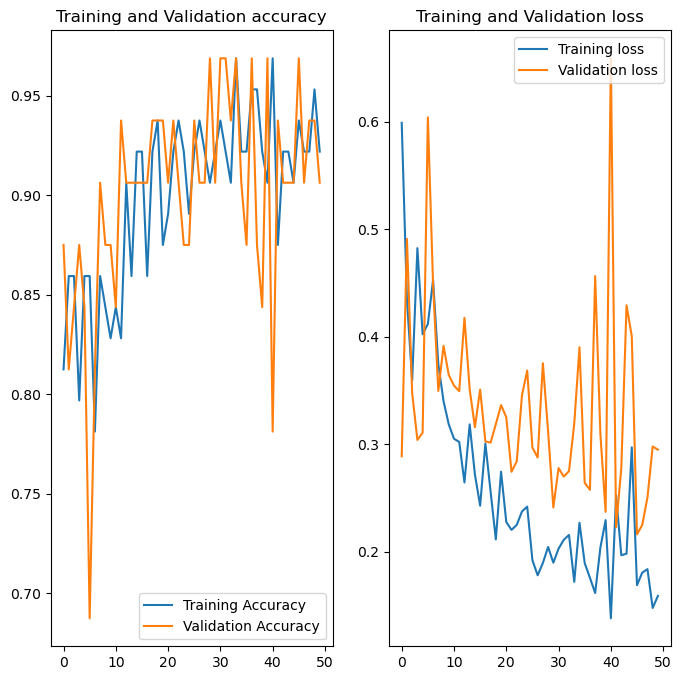

In [ ]:
# Plotting Accuracy and Loss Curves Across
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(Epochs),acc,label = 'Training Accuracy')
plt.plot(range(Epochs),val_acc,label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation accuracy')

plt.subplot(1,2,2)
plt.plot(range(Epochs),loss,label = 'Training loss')
plt.plot(range(Epochs),val_loss,label = 'Validation loss')
plt.legend(loc='upper right')
plt.title('Training and Validation loss')



#### Visualizes training vs. validation accuracy and loss over epochs to assess model learning behavior, detect overfitting, and guide tuning decisions. 
#### Helps interpret how well the model generalizes beyond the training data.

first image to predict
actual label: Bacterial leaf blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
predicted label: Bacterial leaf blight


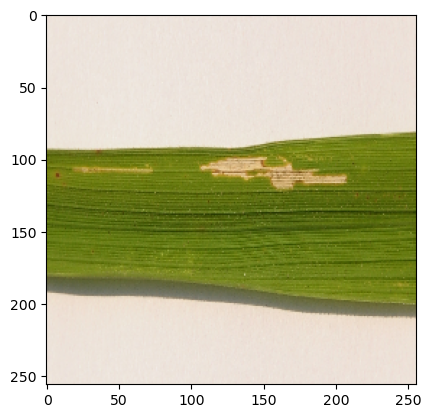

In [ ]:
# Title: Single Image Prediction from Test Batch
for image_batch,label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

#### 1. Displays the first image from the test batch and its actual label to visually inspect input and ground truth.
#### 2. Uses the trained model to predict the label, enabling comparison between predicted and actual class for validation.

In [ ]:
#Custom Image Prediction Function
def predict(model, img):
    # Convert image to array & add batch dimension
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # shape: (1, H, W, C)

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

# 1. Preprocesses a single image and feeds it to the trained model for prediction.
# 2. Returns the predicted class label along with confidence score, enabling real-time inference and result interpretation.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


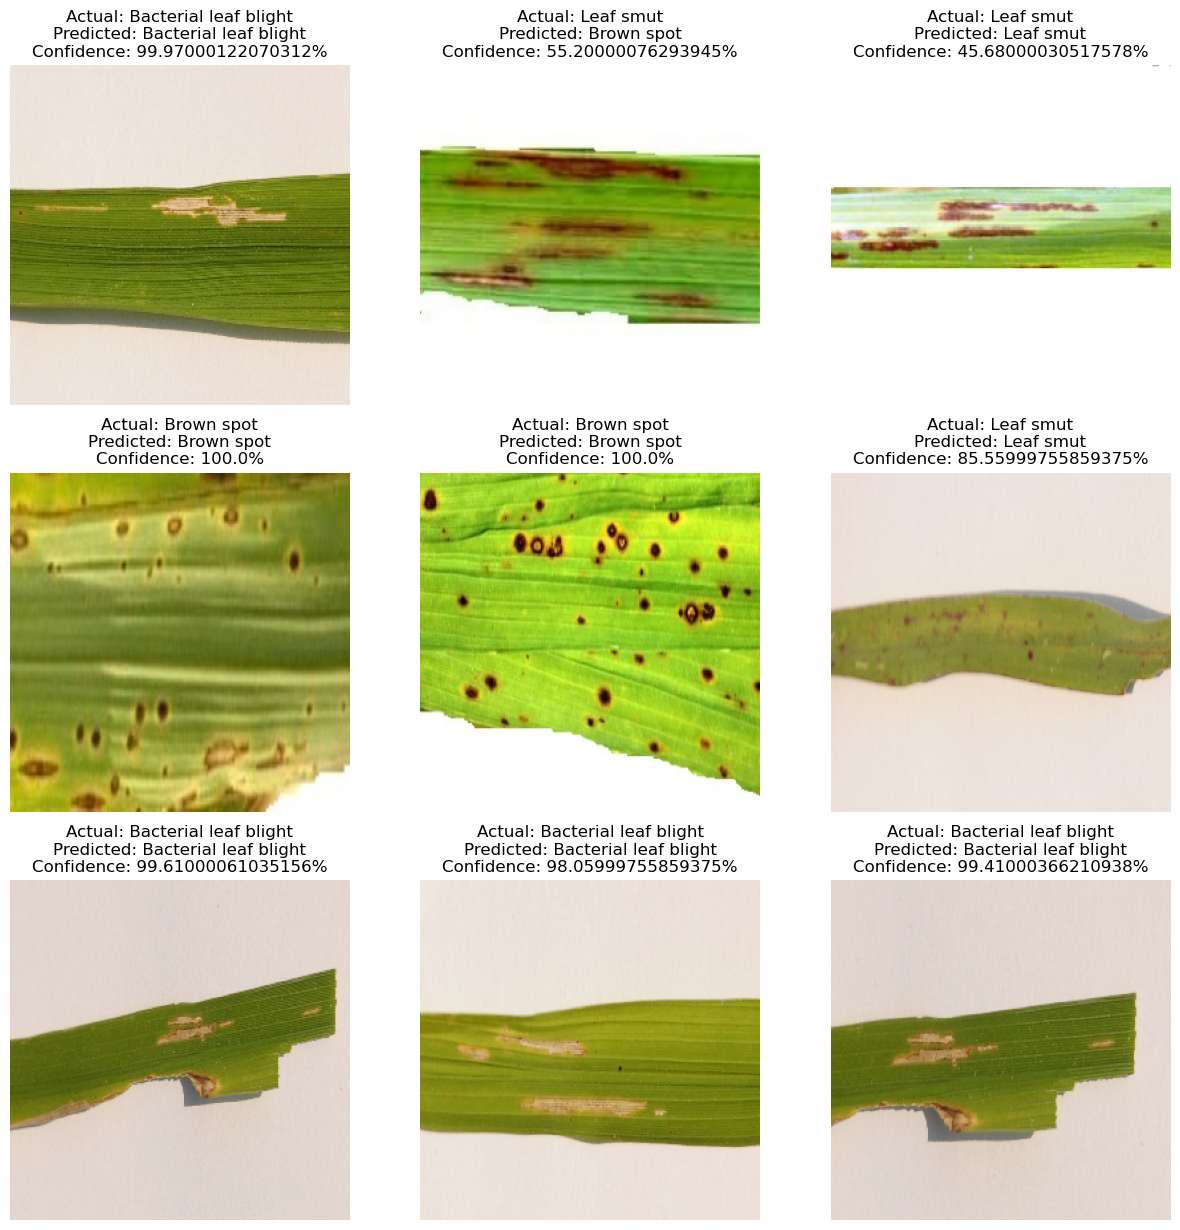

In [ ]:
 # Visual Prediction Grid for Test Images
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis('off')
plt.show()
# 1. Displays a 3×3 grid of test images with actual and predicted labels to visually assess model performance.
# 2. Includes confidence scores for each prediction, helping evaluate certainty and spot potential misclassifications.

## Conclusion Report: Rice Leaf Disease Classification
####  Model Summary
--A deep CNN architecture was built with multiple convolutional and pooling layers, followed by dense layers for classification.

--Data augmentation techniques (random flip and rotation) were applied to improve generalization.

--The model was compiled using the Adam optimizer, Sparse Categorical Crossentropy loss, and accuracy as the evaluation metric.

#### Training Performance
--Final Training Accuracy: 89.06%

--Final Validation Accuracy: 87.50%

--Training Loss: 0.3054

--Validation Loss: 0.3408

--The close alignment between training and validation metrics indicates minimal overfitting and strong generalization.

#### Evaluation & Prediction
--The model was evaluated on unseen test data, confirming its robustness.

--Visual predictions on test images showed high confidence and correct classification in most cases.

--A custom prediction function was implemented for real-time inference with confidence scores.

#### Insights
--The model effectively distinguishes between rice leaf classes with high accuracy.

--Visualization of learning curves helped monitor training dynamics and detect overfitting.

--The architecture and preprocessing pipeline are well-suited for image-based plant disease classification tasks.